In [1]:

import pandas as pd
import matplotlib.pyplot
import sys
sys.path.insert(0, '../../Functions')
from plot_placement import plot_song_prediction_comparison_lstm, plot_xgboost_lstm_comparison
from lstm_model import build_and_evaluate_model, prepare_lstm_data, set_seed
from sklearn.metrics import mean_absolute_error, mean_squared_error


In [2]:
data = pd.read_csv("../../Data/prepared_lstm_data.csv") # Load prepared data for LSTM model

In [3]:
configs = [
    {
        "name": "baseline",
        "lstm_units": [64],
        "dense_units": [32],
        "dropout_rate": 0.2
    },
    {
        "name": "two_lstm",
        "lstm_units": [64, 32],
        "dense_units": [32],
        "dropout_rate": 0.2
    },
    {
        "name": "two_lstm_two_dense",
        "lstm_units": [64, 32],
        "dense_units": [32, 16],
        "dropout_rate": 0.2
    }
]

seeds = [5, 10, 15, 20, 25] # Set of seeds for reproducibility
results = []

In [4]:
# Prepare sets of features for LSTM model
all_audio_features = ['Instrumentalness', 'Danceability', 'Acousticness',
                      'Duration_ms', 'Energy', 'Valence', 'Loudness',
                      'Speechiness', 'Key', 'Mode', 'Time_signature']

audio_features = ['Instrumentalness', 'Danceability', 'Acousticness', 'Duration_ms', 'Energy', 'Valence'] #The most important audio features based on feature importance analysis

all_features = ['Date', 'Song', 'Artist', 'Rank', 'Last Week', 'Weeks in Charts', 
                'Normalized Title', 'rank_change', 'rolling_avg_4_weeks', 'rolling_avg_all_time', 
                'rolling_std_4_weeks', 'rolling_std_all_time', 'target_next_rank'] + all_audio_features

features_max = [
    'Rank',
    'Last Week',
    'Weeks in Charts',
    'rank_change',
    'rolling_avg_4_weeks',
    'rolling_avg_all_time',
    'rolling_std_4_weeks',
    'rolling_std_all_time'
] + all_audio_features


features_audio_selected = [
    'Rank',
    'Last Week',
    'Weeks in Charts',
    'rank_change',
    'rolling_avg_4_weeks',
    'rolling_avg_all_time',
    'rolling_std_4_weeks',
    'rolling_std_all_time'
] + audio_features

features_min = [
    'Rank',
    'Last Week',
    'Weeks in Charts',
]

features_rolling = [
    'Rank',
    'Last Week',
    'Weeks in Charts',
    'rank_change',
    'rolling_avg_4_weeks',
    'rolling_avg_all_time',
    'rolling_std_4_weeks',
    'rolling_std_all_time'
] 

features_no_rolling = [
    'Rank',
    'Last Week',
    'Weeks in Charts',
] + all_audio_features

In [5]:
ready_data = prepare_lstm_data(data, features=features_rolling)

In [ ]:
#test call the function to ensure it works
model, history, mae, rmse = build_and_evaluate_model(ready_data, seq_len=4, lstm_units=[64], dense_units=[32], dropout_rate=0.2, seed=42)
#looks like it works


Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 11: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Epoch 11: early stopping
Restoring model weights from the end of the best epoch: 1.


In [6]:
for config in configs:
    for seed in seeds:
        set_seed(seed)
        print(f"Training model with config: {config['name']} and seed: {seed}")
        model, history, test_mae, test_rmse = build_and_evaluate_model(
            ready_data,
            seq_len=4,
            lstm_units=config["lstm_units"],
            dense_units=config["dense_units"],
            dropout_rate=config["dropout_rate"],
            seed=seed
        )
        
        results.append({
            "config": config["name"],
            "seed": seed,
            "test_mae": test_mae,
            "test_rmse": test_rmse
        })

Training model with config: baseline and seed: 5

Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 11: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 16: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 21: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.

Epoch 28: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.

Epoch 33: ReduceLROnPlateau reducing learning rate to 1.5625000742147677e-05.

Epoch 38: ReduceLROnPlateau reducing learning rate to 7.812500371073838e-06.

Epoch 43: ReduceLROnPlateau reducing learning rate to 3.906250185536919e-06.

Epoch 48: ReduceLROnPlateau reducing learning rate to 1.9531250927684596e-06.
Restoring model weights from the end of the best epoch: 41.
Training model with config: baseline and seed: 10

Epoch 9: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 14: ReduceLROnPlateau reducing learning rate to 0.00025

In [7]:
results_df = pd.DataFrame(results)

summary = (
    results_df
    .groupby("config")
    .agg(
        mean_mae=("test_mae", "mean"),
        std_mae=("test_mae", "std"),
        mean_rmse=("test_rmse", "mean"),
        std_rmse=("test_rmse", "std"),
        min_rmse=("test_rmse", "min"),
        max_rmse=("test_rmse", "max")
    )
    .sort_values("mean_rmse")
)

print(summary)

                    mean_mae   std_mae  mean_rmse  std_rmse  min_rmse  \
config                                                                  
two_lstm            4.679833  0.058701   7.189349  0.029791  7.165917   
baseline            4.656958  0.013730   7.220071  0.026275  7.193884   
two_lstm_two_dense  4.868051  0.271934   7.267404  0.153975  7.147853   

                    max_rmse  
config                        
two_lstm            7.230167  
baseline            7.254186  
two_lstm_two_dense  7.484338  


In [8]:
#check baseline with different features sets
results_baseline = []
sets_to_test = {
    "features_max": features_max,
    "selected_audio_features": features_audio_selected,
    "features_min": features_min,
    "features_no_rolling": features_no_rolling,
    "features_rolling": features_rolling
}

for set_name, feature_set in sets_to_test.items():
    ready_data = prepare_lstm_data(data, features=feature_set)
    for seed in seeds:
        set_seed(seed)
        print(f"Training model with feature set: {set_name} and seed: {seed}")
        model, history, test_mae, test_rmse = build_and_evaluate_model(
            ready_data,
            seq_len=4,
            lstm_units=[64],
            dense_units=[32],
            dropout_rate=0.2,
            seed=seed
        )
        
        results_baseline.append({
            "config": set_name,
            "seed": seed,
            "test_mae": test_mae,
            "test_rmse": test_rmse
        })

Training model with feature set: features_max and seed: 5

Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 12: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 17: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 22: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.

Epoch 28: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.

Epoch 33: ReduceLROnPlateau reducing learning rate to 1.5625000742147677e-05.

Epoch 38: ReduceLROnPlateau reducing learning rate to 7.812500371073838e-06.

Epoch 43: ReduceLROnPlateau reducing learning rate to 3.906250185536919e-06.

Epoch 48: ReduceLROnPlateau reducing learning rate to 1.9531250927684596e-06.
Restoring model weights from the end of the best epoch: 41.
Training model with feature set: features_max and seed: 10

Epoch 9: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 14: ReduceLROnPlateau reducing learni

In [9]:
results_baseline_df = pd.DataFrame(results_baseline)

summary = (
    results_baseline_df
    .groupby("config")
    .agg(
        mean_mae=("test_mae", "mean"),
        std_mae=("test_mae", "std"),
        mean_rmse=("test_rmse", "mean"),
        std_rmse=("test_rmse", "std"),
        min_rmse=("test_rmse", "min"),
        max_rmse=("test_rmse", "max")
    )
    .sort_values("mean_rmse")
)

print(summary)

                         mean_mae   std_mae  mean_rmse  std_rmse  min_rmse  \
config                                                                       
features_min             4.614327  0.012557   7.194374  0.029861  7.159757   
features_no_rolling      4.645036  0.025338   7.213461  0.018681  7.183991   
selected_audio_features  4.649554  0.020782   7.216815  0.036620  7.189322   
features_rolling         4.656958  0.013730   7.220071  0.026275  7.193884   
features_max             4.656323  0.011302   7.231330  0.023185  7.212294   

                         max_rmse  
config                             
features_min             7.235511  
features_no_rolling      7.234841  
selected_audio_features  7.279089  
features_rolling         7.254186  
features_max             7.270623  


TWO LSTM

In [11]:
#check baseline with different features sets
results_2_lstm = []
sets_to_test = {
    "features_max": features_max,
    "selected_audio_features": features_audio_selected,
    "features_min": features_min,
    "features_no_rolling": features_no_rolling,
    "features_rolling": features_rolling
}

for set_name, feature_set in sets_to_test.items():
    ready_data = prepare_lstm_data(data, features=feature_set)
    for seed in seeds:
        set_seed(seed)
        print(f"Training model with feature set: {set_name} and seed: {seed}")
        model, history, test_mae, test_rmse = build_and_evaluate_model(
            ready_data,
            seq_len=4,
            lstm_units=[64, 32],
            dense_units=[32, 16],
            dropout_rate=0.2,
            seed=seed
        )
        
        results_2_lstm.append({
            "config": set_name,
            "seed": seed,
            "test_mae": test_mae,
            "test_rmse": test_rmse
        })

Training model with feature set: features_max and seed: 5

Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 11: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Epoch 14: early stopping
Restoring model weights from the end of the best epoch: 4.
Training model with feature set: features_max and seed: 10

Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 17: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 22: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 27: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.

Epoch 32: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.

Epoch 37: ReduceLROnPlateau reducing learning rate to 1.5625000742147677e-05.
Epoch 40: early stopping
Restoring model weights from the end of the best epoch: 30.
Training model with feature set: features_max and seed: 15

Epoch 9: ReduceLROnPlateau reduc

In [12]:
results_2_lstm_df = pd.DataFrame(results_2_lstm)

summary = (
    results_2_lstm_df
    .groupby("config")
    .agg(
        mean_mae=("test_mae", "mean"),
        std_mae=("test_mae", "std"),
        mean_rmse=("test_rmse", "mean"),
        std_rmse=("test_rmse", "std"),
        min_rmse=("test_rmse", "min"),
        max_rmse=("test_rmse", "max")
    )
    .sort_values("mean_rmse")
)

print(summary)

                         mean_mae   std_mae  mean_rmse  std_rmse  min_rmse  \
config                                                                       
features_min             4.814669  0.207418   7.214474  0.103474  7.149741   
features_rolling         4.868051  0.271934   7.267404  0.153975  7.147853   
selected_audio_features  4.853478  0.175997   7.307024  0.135517  7.146968   
features_no_rolling      4.940692  0.196715   7.322431  0.093538  7.167550   
features_max             5.006053  0.369654   7.391383  0.273096  7.189933   

                         max_rmse  
config                             
features_min             7.396884  
features_rolling         7.484338  
selected_audio_features  7.421231  
features_no_rolling      7.419974  
features_max             7.820912  


In [13]:
#save the best performing model (features_rolling) for future use and reference
#best model - baseline + rolling features
model, history, _, _ = build_and_evaluate_model(prepare_lstm_data(data, features=features_min),
                                                seq_len=4,
                                                lstm_units=[64],
                                                dense_units=[32],
                                                dropout_rate=0.2,
                                                seed=20)


Epoch 8: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 13: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 18: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 23: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.
Epoch 24: early stopping
Restoring model weights from the end of the best epoch: 14.


In [14]:
import joblib
joblib.dump(model, "../Models/LSTM_improved.keras")

['../Models/LSTM_improved.keras']

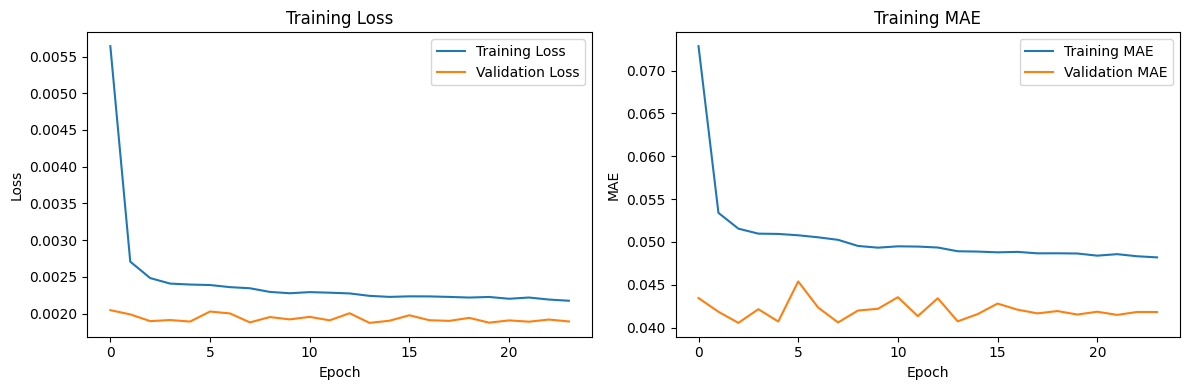

In [15]:
from matplotlib import pyplot as plt
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Training MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.tight_layout()

plt.show()